Load a public dataset, UCI Adult: 

https://archive.ics.uci.edu/dataset/2/adult

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Column names from the UCI Adult dataset
column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num", 
    "marital-status", "occupation", "relationship", "race", "sex", 
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income" 
]

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
adult_df = pd.read_csv(url, names=column_names, sep=',\\s*', engine='python')

# Show the first few rows
print(adult_df.head())

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

We will first do some data cleaning and treat data samples with missing values

In [ ]:
# Remove rows with missing values
adult_df.replace('?', np.nan, inplace=True)
adult_df.dropna(inplace=True)

Now we will look into various popular data visualization techniques.

First, we will look into Bar Plots which are suitable for visualizing nominal / categorical data. We have a look at the feature "workclass".

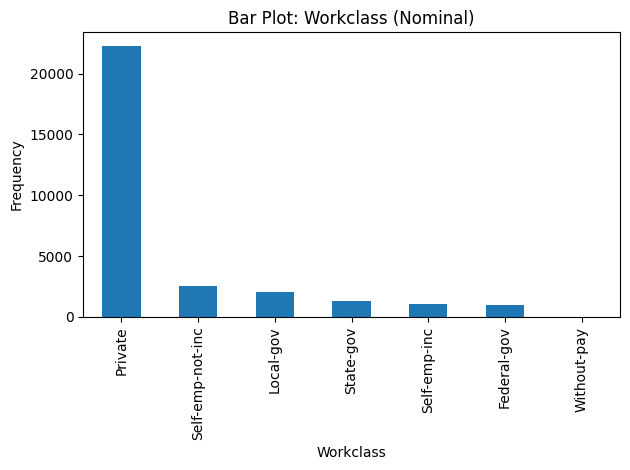

In [ ]:
# with matplotlib and panda:
# ----------- 1. Bar Plot: Workclass (Nominal) -----------
fig1, ax1 = plt.subplots()
adult_df["workclass"].value_counts().plot(kind="bar", ax=ax1)
ax1.set_title("Bar Plot: Workclass (Nominal)")
ax1.set_ylabel("Frequency")
ax1.set_xlabel("Workclass")
plt.tight_layout()
plt.show()


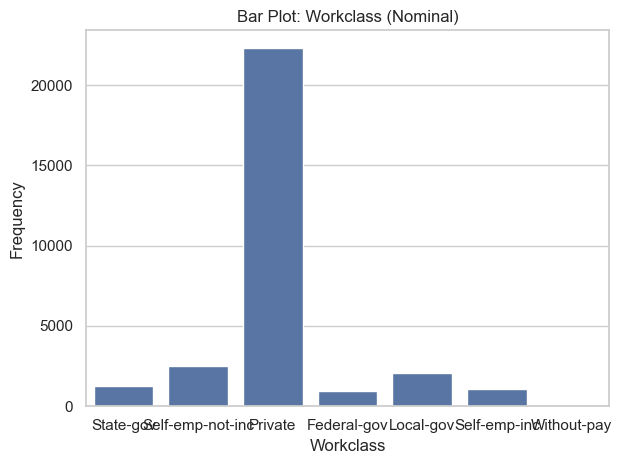

In [ ]:
# or with seaborn:

# Set Seaborn style
sns.set(style="whitegrid")

fig1b, ax1b = plt.subplots()

sns.countplot(data=adult_df, x="workclass", ax=ax1b)

ax1b.set_title("Bar Plot: Workclass (Nominal)")
ax1b.set_ylabel("Frequency")
ax1b.set_xlabel("Workclass")

plt.tight_layout()
plt.show()

If we have ordinal data, we can also used an ordered Bar Plot. 

We ivestigate the feature "education". First, we define the natural ordering of education levels. Then, we create an ordered Bar Plot using the defined ordering.

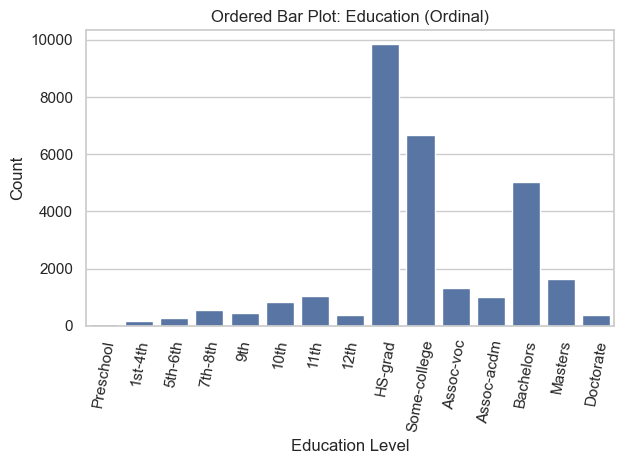

In [ ]:
# ----------- 2. Ordered Bar Plot: Education (Ordinal) -----------
# Natural order of education levels
education_order = [
    "Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
    "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm",
    "Bachelors", "Masters", "Doctorate"
]
fig2, ax2 = plt.subplots()
sns.countplot(x="education", data=adult_df, order=education_order, ax=ax2)
ax2.set_title("Ordered Bar Plot: Education (Ordinal)")
ax2.set_ylabel("Count")
ax2.set_xlabel("Education Level")
ax2.tick_params(axis='x', rotation=80)
plt.tight_layout()
plt.show()

Another popular plot is the Box Plot. Again, we have a look at the education feature.

A Box Plot shows the 0.25 quantile (Q1, lower box end), 0.5 quantile or median (Q2, middle line), 0.75 quantile (Q3, upper box end). 

The max value is computed from Q3 + 1.5*(Q3-Q1) where Q3-Q1 is called the interquartile range IQR. Seaborn uses the highest data point ≤ that threshold. 
Similarily, the min value is computed and plotted. The remaining data points are considered outliers.

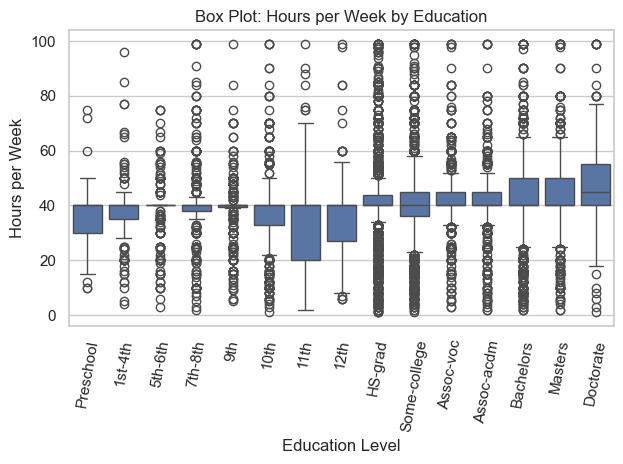

In [ ]:
# ----------- 3. Box Plot: Hours-per-week by Education (Ordinal) -----------
fig3, ax3 = plt.subplots()
sns.boxplot(x="education", y="hours-per-week", data=adult_df, order=education_order, ax=ax3)
ax3.set_title("Box Plot: Hours per Week by Education")
ax3.set_xlabel("Education Level")
ax3.set_ylabel("Hours per Week")
ax3.tick_params(axis='x', rotation=80)
plt.tight_layout()
plt.show()

For interval data, we may want to use a histogram. The key parameter is the number of bins to be used.

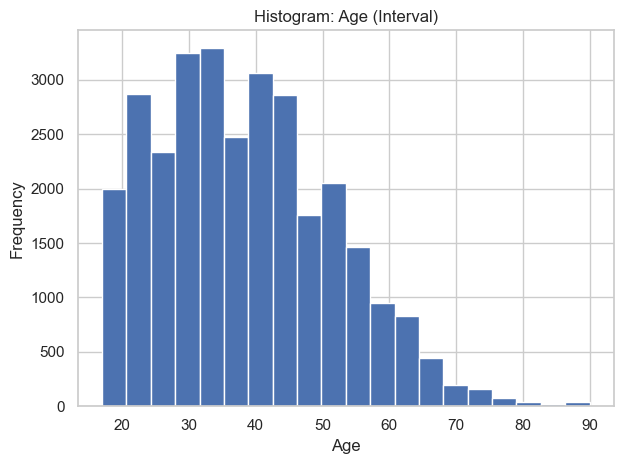

In [ ]:
# ----------- 4. Histogram: Age (Interval) -----------
fig4, ax4 = plt.subplots()
adult_df["age"].plot(kind="hist", bins=20, ax=ax4)
ax4.set_title("Histogram: Age (Interval)")
ax4.set_xlabel("Age")
plt.tight_layout()
plt.show()

<Axes: xlabel='age', ylabel='Count'>

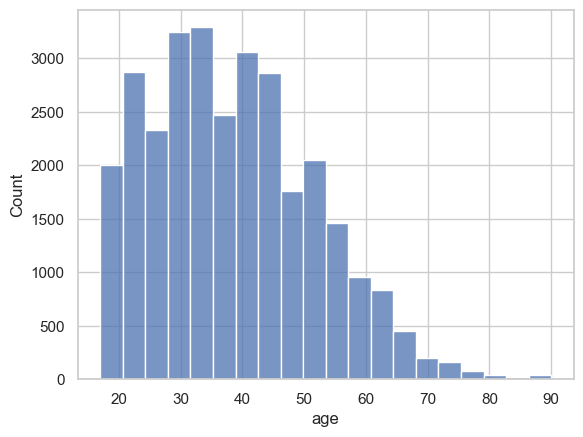

In [ ]:
# or with seaborn:
sns.histplot(adult_df["age"], bins=20)


Another popular plot is the Scatter Plot that can be used for interval or ratio data.

Here we have a look at Age vs. Hours-a-week. Note that there are some surprising entries for old people in the dataset.

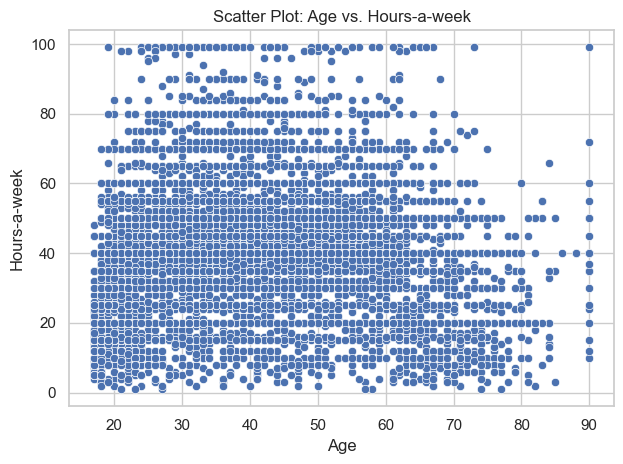

In [ ]:
# ----------- 5. Scatter Plot: Age vs. Hours-a-week (Interval) -----------
fig5, ax5 = plt.subplots()
sns.scatterplot(x="age", y="hours-per-week", data=adult_df, ax=ax5)
ax5.set_title("Scatter Plot: Age vs. Hours-a-week")
ax5.set_xlabel("Age")
ax5.set_ylabel("Hours-a-week")
plt.tight_layout()
plt.show()

In [ ]:
And finally, for ratio data, we can also do a Line Plot.

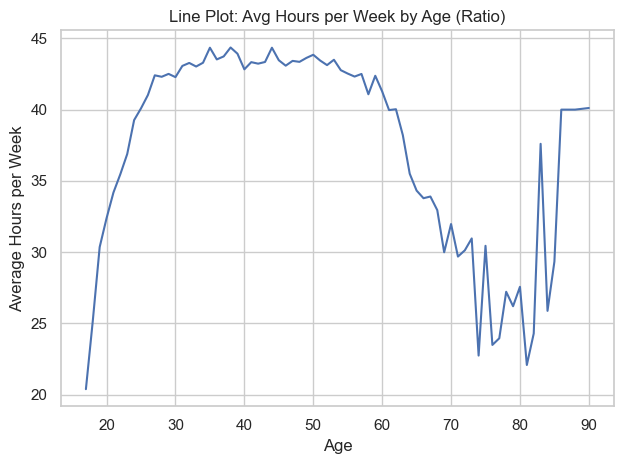

In [ ]:
# ----------- 6. Line Plot: Avg Hours-per-week by Age (Ratio) -----------
line_data = adult_df.groupby("age")["hours-per-week"].mean().reset_index() #reset_index() transforms group index back to column: 2 cols now
fig6, ax6 = plt.subplots()
sns.lineplot(x="age", y="hours-per-week", data=line_data, ax=ax6)
ax6.set_title("Line Plot: Avg Hours per Week by Age (Ratio)")
ax6.set_xlabel("Age")
ax6.set_ylabel("Average Hours per Week")
plt.tight_layout()
plt.show()
